# WELCOME TO CRESENCIO'S DATA VISUALIZATION PRACTICE

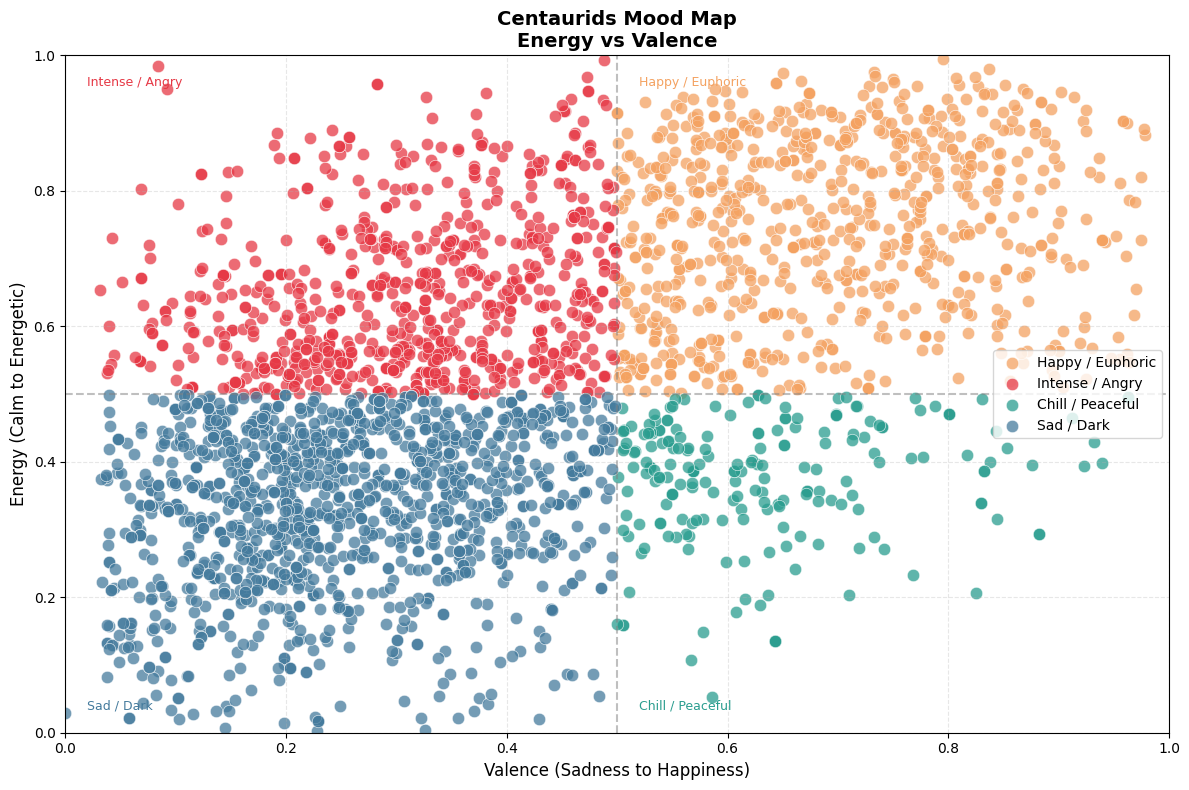


Your Mood Breakdown:
Mood
Sad / Dark          1326
Intense / Angry      787
Happy / Euphoric     782
Chill / Peaceful     206


In [19]:
# VISUALIZATION 1: Your Music Mood Map — Energy vs Valence (Fixed)

import matplotlib as mpl

# Fix: Reset font to default before anything else
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['font.family'] = 'DejaVu Sans'

# Step 1: Assign mood quadrant per song
def get_mood(row):
    if row['Energy'] >= 0.5 and row['Valence'] >= 0.5:
        return 'Happy / Euphoric'
    elif row['Energy'] >= 0.5 and row['Valence'] < 0.5:
        return 'Intense / Angry'
    elif row['Energy'] < 0.5 and row['Valence'] >= 0.5:
        return 'Chill / Peaceful'
    else:
        return 'Sad / Dark'

df['Mood'] = df.apply(get_mood, axis=1)

# Step 2: Assign colors per mood
mood_colors = {
    'Happy / Euphoric': '#f4a261',
    'Intense / Angry' : '#e63946',
    'Chill / Peaceful': '#2a9d8f',
    'Sad / Dark'      : '#457b9d'
}

# Step 3: Plot the mood map
fig, ax = plt.subplots(figsize=(12, 8))

for mood, color in mood_colors.items():
    subset = df[df['Mood'] == mood]
    ax.scatter(
        subset['Valence'],
        subset['Energy'],
        c=color,
        label=mood,
        alpha=0.75,
        s=80,
        edgecolors='white',
        linewidths=0.5
    )

# Step 4: Add quadrant dividers and labels (no arrows, no emojis)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5)
ax.text(0.02, 0.97, 'Intense / Angry',  transform=ax.transAxes, fontsize=9, color='#e63946', va='top')
ax.text(0.52, 0.97, 'Happy / Euphoric', transform=ax.transAxes, fontsize=9, color='#f4a261', va='top')
ax.text(0.02, 0.03, 'Sad / Dark',        transform=ax.transAxes, fontsize=9, color='#457b9d', va='bottom')
ax.text(0.52, 0.03, 'Chill / Peaceful', transform=ax.transAxes, fontsize=9, color='#2a9d8f', va='bottom')

# Step 5: Add labels and formatting
ax.set_xlabel('Valence (Sadness to Happiness)', fontsize=12)
ax.set_ylabel('Energy (Calm to Energetic)',      fontsize=12)
ax.set_title('Centaurids Mood Map\nEnergy vs Valence', fontsize=14, fontweight='bold')
ax.legend(loc='center right', framealpha=0.8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 6: Print mood breakdown
print("\nYour Mood Breakdown:")
print(df['Mood'].value_counts().to_string())

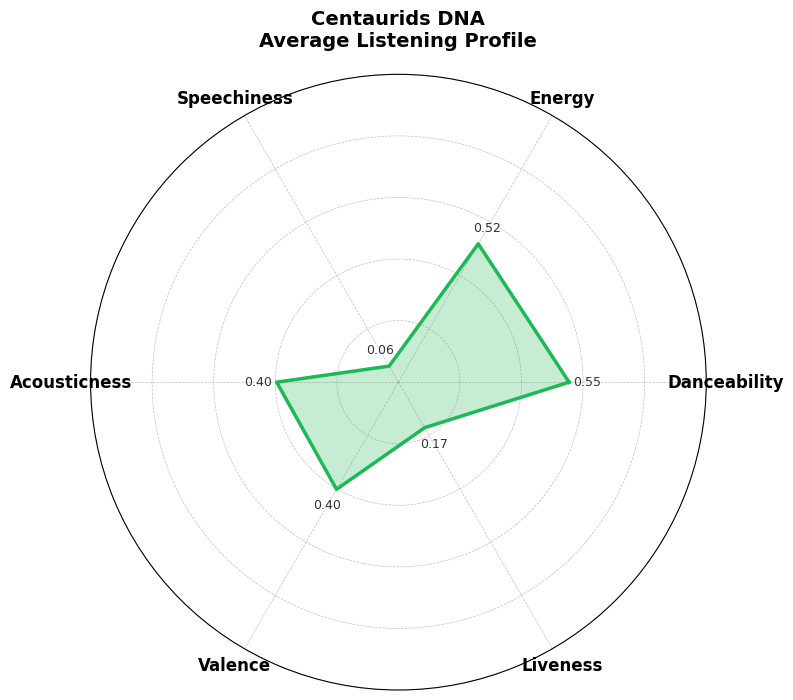


🎧 Your Average Audio Profile:
  Danceability    0.554  ███████████
  Energy          0.519  ██████████
  Speechiness     0.060  █
  Acousticness    0.395  ███████
  Valence         0.402  ████████
  Liveness        0.171  ███


In [20]:
# VISUALIZATION 2: Your Audio DNA — Radar Chart of Average Audio Features

import matplotlib.pyplot as plt
import numpy as np

# FIX: Use DejaVu Sans (guaranteed available, has all Latin glyphs)
plt.rcParams['font.family'] = 'DejaVu Sans'

# Step 1: Select the 6 audio feature dimensions (all scaled 0-1)
features   = ['Danceability', 'Energy', 'Speechiness',
               'Acousticness', 'Valence', 'Liveness']

df_features = df[features].dropna()
avg_values  = df_features.mean().values.tolist()
avg_values += avg_values[:1]    # Close the radar loop

# Step 2: Set up radar chart angles
angles  = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]            # Close the loop

# Step 3: Plot the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, avg_values, color='#1DB954', linewidth=2.5, linestyle='solid')
ax.fill(angles, avg_values, color='#1DB954', alpha=0.25)

# Step 4: Add feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, fontweight='bold')

# Step 5: Add value annotations on each axis point
for angle, value in zip(angles[:-1], avg_values[:-1]):
    ax.text(
        angle, value + 0.06,
        f'{value:.2f}',
        ha='center', va='center',
        fontsize=9, color='#333333'
    )

# Step 6: Style and display
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title(
    'Centaurids DNA\nAverage Listening Profile',
    fontsize=14, fontweight='bold',
    pad=20
)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# Step 7: Print the values
print("\n🎧 Your Average Audio Profile:")
for feat, val in zip(features, avg_values[:-1]):
    bar = '█' * int(val * 20)
    print(f"  {feat:<15} {val:.3f}  {bar}")

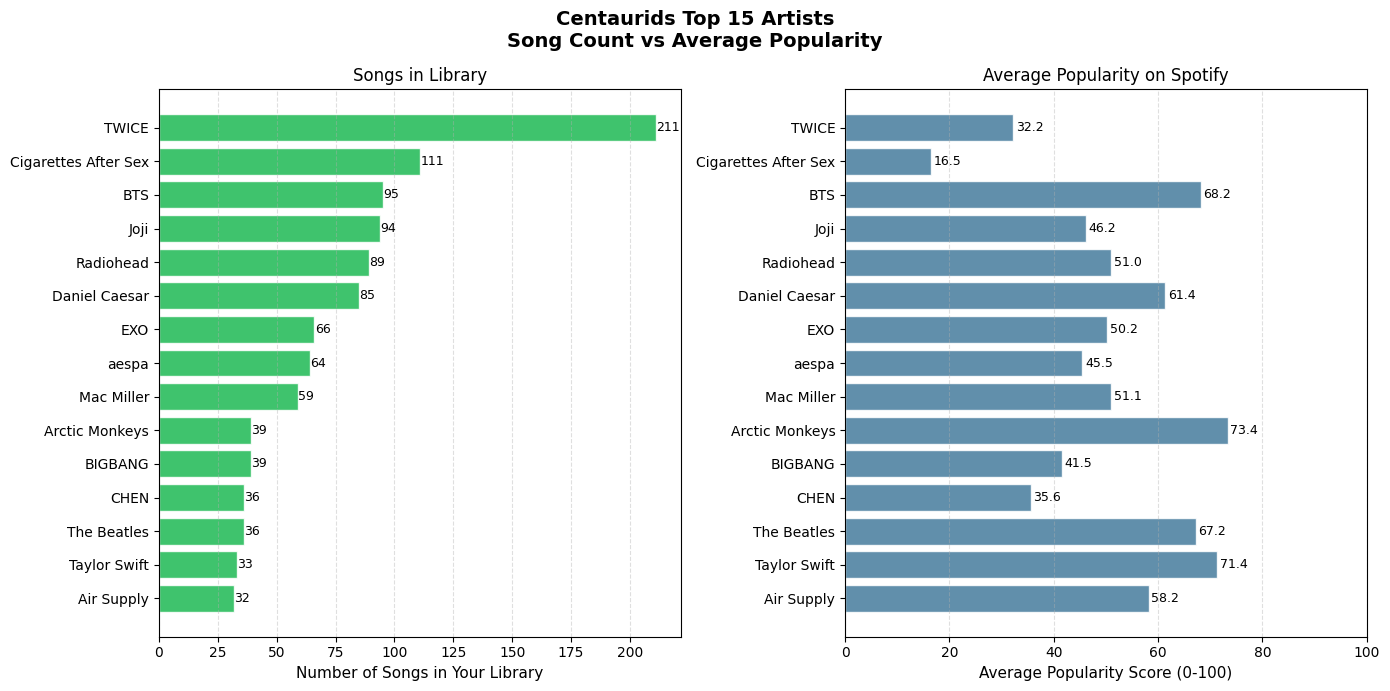


🎤 Your Top 15 Artists Summary:
                      Song Count  Avg Popularity
Primary Artist                                  
TWICE                        211       32.236967
Cigarettes After Sex         111       16.486486
BTS                           95       68.200000
Joji                          94       46.180851
Radiohead                     89       51.011236
Daniel Caesar                 85       61.388235
EXO                           66       50.212121
aespa                         64       45.468750
Mac Miller                    59       51.050847
Arctic Monkeys                39       73.358974
BIGBANG                       39       41.512821
CHEN                          36       35.555556
The Beatles                   36       67.222222
Taylor Swift                  33       71.363636
Air Supply                    32       58.218750


In [21]:
# VISUALIZATION 3: Your Top Artists — Song Count vs Average Popularity

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# FIX: Use DejaVu Sans to avoid missing glyph warnings
plt.rcParams['font.family'] = 'DejaVu Sans'

# Step 1: Compute song count and average popularity per primary artist
artist_count = df.groupby('Primary Artist').size().rename('Song Count')
artist_pop   = df.groupby('Primary Artist')['Popularity'].mean().rename('Avg Popularity')
artist_df    = pd.concat([artist_count, artist_pop], axis=1)

# Step 2: Get top 15 artists by song count, sorted ascending for barh
top15 = artist_df.nlargest(15, 'Song Count').sort_values('Song Count', ascending=True)

# Step 3: Create dual horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    'Centaurids Top 15 Artists\nSong Count vs Average Popularity',
    fontsize=14, fontweight='bold'
)

# Step 4: Left — Song Count bars
bars1 = ax1.barh(top15.index, top15['Song Count'], color='#1DB954', alpha=0.85, edgecolor='white')
ax1.set_xlabel('Number of Songs in Your Library', fontsize=11)
ax1.set_title('Songs in Library', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4, axis='x')
for bar in bars1:
    ax1.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center', fontsize=9
    )

# Step 5: Right — Average Popularity bars
bars2 = ax2.barh(top15.index, top15['Avg Popularity'], color='#457b9d', alpha=0.85, edgecolor='white')
ax2.set_xlabel('Average Popularity Score (0-100)', fontsize=11)
ax2.set_title('Average Popularity on Spotify', fontsize=12)
ax2.set_xlim(0, 100)
ax2.grid(True, linestyle='--', alpha=0.4, axis='x')
for bar in bars2:
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}',
        va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

# Step 6: Print summary table
print("\n🎤 Your Top 15 Artists Summary:")
print(top15.sort_values('Song Count', ascending=False).to_string())

Font reset to default!


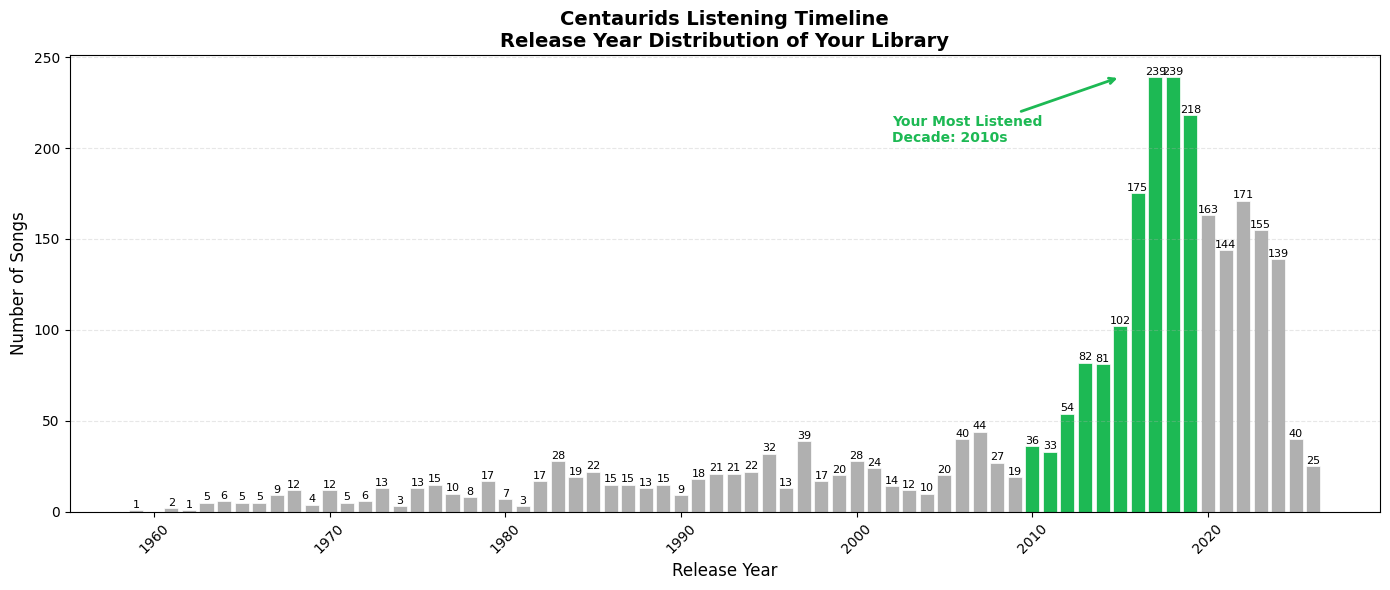


Oldest song year : 1959
Newest song year : 2026
Most common year : 2017 (239 songs)
Most common decade: 2010s


In [22]:
# VISUALIZATION 4: Your Listening Timeline — When Were Your Songs Released?
# Shows the distribution of release years in your library with
# a highlight on your most popular decade

# CELL: Reset font back to default — run this once before any visualization

import matplotlib.pyplot as plt
import matplotlib as mpl

# Reset font to default so regular text renders correctly
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Font reset to default!")

# Step 1: Extract release year from Release Date column
df['Release Year'] = pd.to_datetime(df['Release Date'], errors='coerce').dt.year
df_year = df.dropna(subset=['Release Year'])
df_year['Release Year'] = df_year['Release Year'].astype(int)

# Step 2: Count songs per year
year_counts = df_year['Release Year'].value_counts().sort_index()

# Step 3: Find your most common decade
df_year['Decade'] = (df_year['Release Year'] // 10) * 10
top_decade = df_year['Decade'].value_counts().idxmax()

# Step 4: Assign bar colors — highlight the top decade
bar_colors = [
    '#1DB954' if (year // 10) * 10 == top_decade else '#b0b0b0'
    for year in year_counts.index
]

# Step 5: Plot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    year_counts.index,
    year_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)

# Step 6: Add value labels on top of each bar
for bar in bars:
    if bar.get_height() > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=8
        )

# Step 7: Add decade annotation
ax.annotate(
    f'Your Most Listened\nDecade: {top_decade}s',
    xy=(top_decade + 5, year_counts[year_counts.index // 10 * 10 == top_decade].max()),
    xytext=(top_decade - 8, year_counts.max() * 0.85),
    arrowprops=dict(arrowstyle='->', color='#1DB954', lw=2),
    fontsize=10, color='#1DB954', fontweight='bold'
)

# Step 8: Labels and formatting
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Songs', fontsize=12)
ax.set_title(
    'Centaurids Listening Timeline\nRelease Year Distribution of Your Library',
    fontsize=14, fontweight='bold'
)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 9: Print summary
print(f"\nOldest song year : {int(df_year['Release Year'].min())}")
print(f"Newest song year : {int(df_year['Release Year'].max())}")
print(f"Most common year : {int(year_counts.idxmax())} ({year_counts.max()} songs)")
print(f"Most common decade: {top_decade}s")

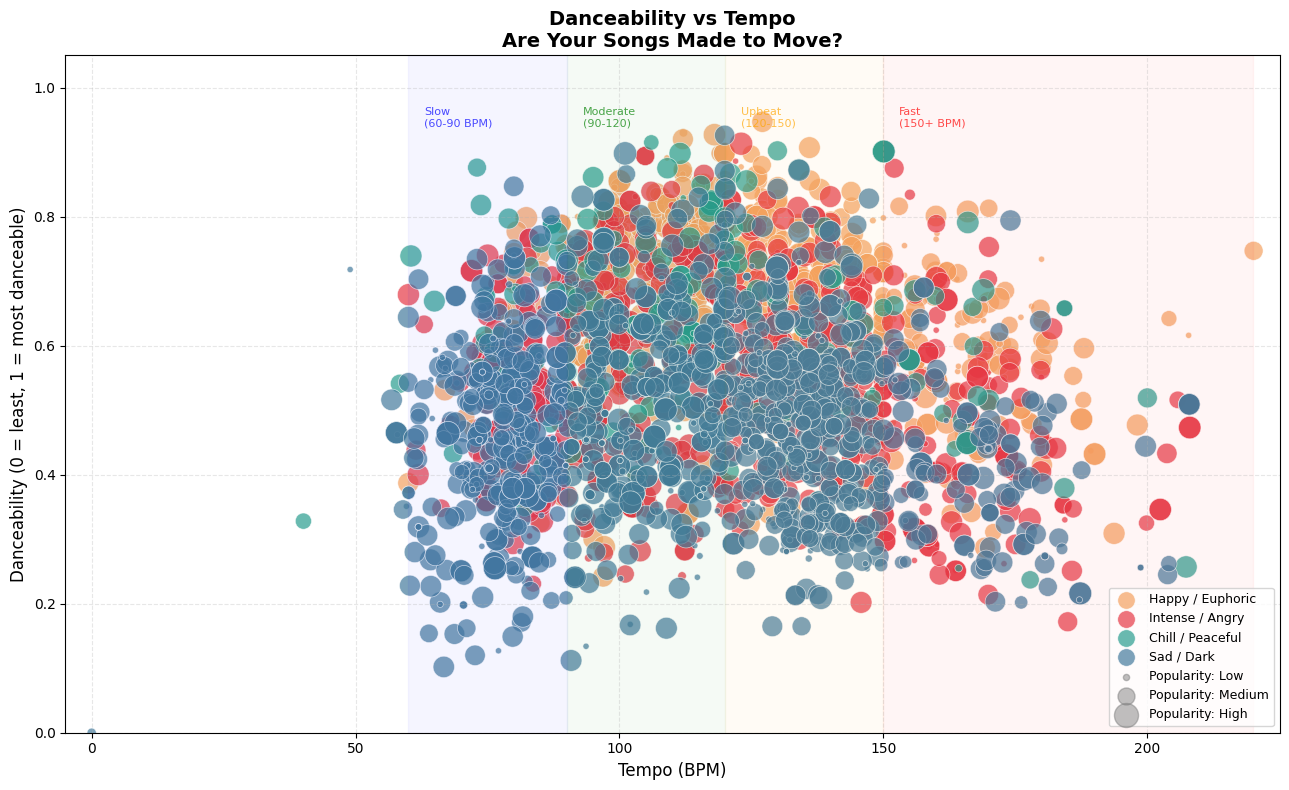


Average Tempo      : 117.5 BPM
Most Danceable Song: Uuuu
Least Danceable    : Ww
Fastest Song       : Cigarette (220 BPM)
Slowest Song       : Ww (0 BPM)


In [23]:
# VISUALIZATION 5: Your Danceability vs Tempo — Are Your Songs Made to Move?
# Plots each song's tempo (BPM) against danceability,
# sized by popularity and colored by mood

# Step 1: Make sure Mood column exists (run Visualization 1 first)
# If not, rerun the get_mood function and apply it
if 'Mood' not in df.columns:
    def get_mood(row):
        if row['Energy'] >= 0.5 and row['Valence'] >= 0.5:
            return 'Happy / Euphoric'
        elif row['Energy'] >= 0.5 and row['Valence'] < 0.5:
            return 'Intense / Angry'
        elif row['Energy'] < 0.5 and row['Valence'] >= 0.5:
            return 'Chill / Peaceful'
        else:
            return 'Sad / Dark'
    df['Mood'] = df.apply(get_mood, axis=1)

# Step 2: Drop rows with missing values in needed columns
df_dance = df.dropna(subset=['Tempo', 'Danceability', 'Popularity', 'Mood']).copy()

# Step 3: Normalize popularity for bubble size (min 20, max 300)
size_scaled = (
    (df_dance['Popularity'] - df_dance['Popularity'].min()) /
    (df_dance['Popularity'].max() - df_dance['Popularity'].min())
) * 280 + 20

# Step 4: Mood colors (reuse same palette as Visualization 1)
mood_colors = {
    'Happy / Euphoric': '#f4a261',
    'Intense / Angry' : '#e63946',
    'Chill / Peaceful': '#2a9d8f',
    'Sad / Dark'      : '#457b9d'
}

# Step 5: Plot
fig, ax = plt.subplots(figsize=(13, 8))

for mood, color in mood_colors.items():
    subset      = df_dance[df_dance['Mood'] == mood]
    subset_size = size_scaled[subset.index]
    ax.scatter(
        subset['Tempo'],
        subset['Danceability'],
        c=color,
        s=subset_size,
        label=mood,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5
    )

# Step 6: Add BPM zone labels
ax.axvspan(60,  90,  alpha=0.04, color='blue',   label='_nolegend_')
ax.axvspan(90,  120, alpha=0.04, color='green',  label='_nolegend_')
ax.axvspan(120, 150, alpha=0.04, color='orange', label='_nolegend_')
ax.axvspan(150, 220, alpha=0.04, color='red',    label='_nolegend_')

ax.text(63,  0.97, 'Slow\n(60-90 BPM)',    fontsize=8, color='blue',   va='top', alpha=0.7)
ax.text(93,  0.97, 'Moderate\n(90-120)',   fontsize=8, color='green',  va='top', alpha=0.7)
ax.text(123, 0.97, 'Upbeat\n(120-150)',    fontsize=8, color='orange', va='top', alpha=0.7)
ax.text(153, 0.97, 'Fast\n(150+ BPM)',     fontsize=8, color='red',    va='top', alpha=0.7)

# Step 7: Add a size legend for popularity
for pop, label in zip([20, 150, 300], ['Low', 'Medium', 'High']):
    ax.scatter([], [], s=pop, c='grey', alpha=0.5, label=f'Popularity: {label}')

# Step 8: Labels and formatting
ax.set_xlabel('Tempo (BPM)', fontsize=12)
ax.set_ylabel('Danceability (0 = least, 1 = most danceable)', fontsize=12)
ax.set_title(
    'Danceability vs Tempo\nAre Your Songs Made to Move?',
    fontsize=14, fontweight='bold'
)
ax.set_xlim(df_dance['Tempo'].min() - 5, df_dance['Tempo'].max() + 5)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', framealpha=0.8, fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 9: Print summary stats
print(f"\nAverage Tempo      : {df_dance['Tempo'].mean():.1f} BPM")
print(f"Most Danceable Song: {df_dance.loc[df_dance['Danceability'].idxmax(), 'Track Name']}")
print(f"Least Danceable    : {df_dance.loc[df_dance['Danceability'].idxmin(), 'Track Name']}")
print(f"Fastest Song       : {df_dance.loc[df_dance['Tempo'].idxmax(), 'Track Name']} ({df_dance['Tempo'].max():.0f} BPM)")
print(f"Slowest Song       : {df_dance.loc[df_dance['Tempo'].idxmin(), 'Track Name']} ({df_dance['Tempo'].min():.0f} BPM)")

In [24]:
# GIF: Audio DNA Radar — Morphing Per Top Artist
# Shows how each of your top artists has a unique audio fingerprint

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import numpy as np
import os
import webbrowser

# Step 1: Select audio features and top artists
features = ['Danceability', 'Energy', 'Speechiness',
            'Acousticness', 'Valence', 'Liveness']

top_artists = df['Primary Artist'].value_counts().head(8).index.tolist()
df_artists  = df[df['Primary Artist'].isin(top_artists)].dropna(subset=features)

# Step 2: Compute average feature values per artist
artist_profiles = df_artists.groupby('Primary Artist')[features].mean()

# Step 3: Radar setup
angles  = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

artist_colors = [
    '#1DB954', '#e63946', '#f4a261', '#457b9d',
    '#2a9d8f', '#9b5de5', '#f15bb5', '#fee440'
]

# Step 4: Initialize figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

def animate(i):
    ax.clear()

    artist = top_artists[i]
    color  = artist_colors[i % len(artist_colors)]
    values = artist_profiles.loc[artist].values.tolist()
    values += values[:1]

    # Step 5: Plot radar for current artist
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)

    # Step 6: Add feature labels and value annotations
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=11, fontweight='bold')
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.text(
            angle, value + 0.07,
            f'{value:.2f}',
            ha='center', va='center',
            fontsize=8, color='#333333'
        )

    # Step 7: Formatting
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(
        f'Audio DNA\n{artist}  ({i+1}/{len(top_artists)})',
        fontsize=13, fontweight='bold', pad=20, color=color
    )
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)

# Step 8: Build animation — hold each artist for 20 frames
def animate_with_hold(frame):
    artist_idx = frame // 20
    if artist_idx >= len(top_artists):
        artist_idx = len(top_artists) - 1
    animate(artist_idx)

total_frames = len(top_artists) * 20

ani = animation.FuncAnimation(
    fig, animate_with_hold,
    frames=total_frames,
    interval=80,
    repeat=True
)

# Step 9: Save and open
gif_path = os.path.abspath("audio_dna_per_artist.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f"GIF saved at: {gif_path}")
webbrowser.open(f"file://{gif_path}")
plt.close(fig)

GIF saved at: /home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Data_Visualization_Practice/audio_dna_per_artist.gif


# THE END OF CRESENIO'S DATA VISUALIZATION PRACTICE
**HOPE YOU LIKE IT!**